In [8]:
pip install mne seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\ferna\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [ ]:
pip install mne seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\ferna\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [ ]:
import openneuro as on

dataset_id = 'ds006803'
download_dir = './data_openneuro'

print(f"Iniciando la descarga del dataset: {dataset_id}...")

# Descarga el dataset completo
on.download(dataset=dataset_id, target_dir=download_dir)

print(f"Descarga completada en: {download_dir}")

## Descargar solo los archivos relacionados con una sesión específica
#on.download(dataset=dataset_id, target_dir=download_dir, include=['sub-01e'])

Iniciando la descarga del dataset: ds006803...

👋 Hello! This is openneuro-py 2023.1.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds006803 …


📁 Traversing directories for ds006803 : 0 entities [00:00, ? entities/s]

📥 Retrieving up to 7 files (5 concurrent downloads). 
✅ Finished downloading ds006803.
 
🧠 Please enjoy your brains.
 
Descarga completada en: ./data_openneuro


Re-downloading .bidsignore: file size mismatch.: 0.00B [00:00, ?B/s]

Re-downloading README: file size mismatch.: 0.00B [00:00, ?B/s]

Re-downloading dataset_description.json: file size mismatch.: 0.00B [00:00, ?B/s]

Re-downloading CHANGES: file size mismatch.: 0.00B [00:00, ?B/s]

Re-downloading extra_metadata.xlsx: file size mismatch.: 0.00B [00:00, ?B/s]

Re-downloading participants.tsv: file size mismatch.: 0.00B [00:00, ?B/s]

Re-downloading participants.json: file size mismatch.: 0.00B [00:00, ?B/s]

In [16]:
# Libraries
import pandas as pd
import numpy as np
import mne
from pathlib import Path
from scipy.signal.windows import gaussian
from mne.time_frequency import tfr_array_morlet

In [2]:
main_path = 'data_openneuro'

outliers = [
    'sub-1e', 'sub-3e', 'sub-4e', 'sub-6e', 'sub-9e', 'sub-10e', 'sub-12e', 
    'sub-14e', 'sub-15e', 'sub-24e', 'sub-25e', 'sub-33e', 'sub-34e', 
    'sub-36e', 'sub-37e', 'sub-39e', 'sub-40e', 'sub-41e', 'sub-14c', 'sub-16c'
]
# Subjects lit
sub_list = pd.read_csv(f'{main_path}/participants.tsv',  sep='\t')
sub_list = sub_list[~sub_list['participant_id'].isin(outliers)].reset_index(drop=True)
print(sub_list.head())





  participant_id  Gender  Age Group
0        sub-01c    Male   19   con
1        sub-02c    Male   19   con
2        sub-03c  Female   19   con
3        sub-04c    Male   20   con
4        sub-05c    Male   19   con


In [17]:
CWT_DIR = Path('D:/cwt_results_complex/beta')
freqs = np.linspace(12, 30, num=24)

"""
CWT_DIR = Path('D:/cwt_results_complex/beta')
freqs = np.linspace(12, 30, num=24)
CWT_DIR = Path('D:/cwt_results_complex/theta')
freqs = np.linspace(4, 8, num=12)
CWT_DIR = Path('D:/cwt_results_complex/delta')
freqs = np.linspace(1, 8, num=12)

CWT_DIR = Path('D:/cwt_results_complex/alpha-beta_base')
freqs = np.linspace(8, 30, num=24)
CWT_DIR = Path('D:/cwt_results_complex/theta-alpha_base')
freqs = np.linspace(4, 12, num=12)
"""

"\nCWT_DIR = Path('D:/cwt_results_complex/beta')\nfreqs = np.linspace(12, 30, num=24)\nCWT_DIR = Path('D:/cwt_results_complex/theta')\nfreqs = np.linspace(4, 8, num=12)\nCWT_DIR = Path('D:/cwt_results_complex/delta')\nfreqs = np.linspace(1, 8, num=12)\n\nCWT_DIR = Path('D:/cwt_results_complex/alpha-beta_base')\nfreqs = np.linspace(8, 30, num=24)\nCWT_DIR = Path('D:/cwt_results_complex/theta-alpha_base')\nfreqs = np.linspace(4, 12, num=12)\n"

In [13]:
#Cálculo de Wavelets

import numpy as np
import pandas as pd
import mne
from mne.time_frequency import tfr_array_morlet
from pathlib import Path
from scipy.signal.windows import gaussian

# Configuración
CWT_DIR.mkdir(exist_ok=True)
target_channels = ['Fz', 'C3', 'C4', 'Cz', 'Pz', 'PO7', 'PO8', 'Oz']

n_cycles = freqs / 2

for index, row in sub_list.iterrows():
    sub_id = row['participant_id']
    #Carga de datos 
    raw = mne.io.read_raw_eeglab(f'{main_path}/{sub_id}/ses-2/eeg/{sub_id}_ses-2_task-STEMSKILLS_eeg.set')
    raw.pick_channels(target_channels)
    
    fs = raw.info['sfreq']
    df_events = pd.read_csv(f'{main_path}/{sub_id}/arithmetic_responses.csv')
    
    # Preparación de épocas
    quest_samples = (df_events['Question_appearance'] * fs - 3 * fs).astype(int)
    ans_samples = (df_events['Answer_time'] * fs - 3 * fs).astype(int)

    #segment_baseline_raw = raw.copy().crop(tmin=3, tmax=(120 - 3))
    #segment_baseline = segment_baseline_raw.get_data().astype(np.float32)
    
    all_epochs_complex = []

    print(f'Calculando Wavelets de {sub_id}...')
    for i in range(len(quest_samples)):
        t_start = quest_samples[i] / fs 
        t_end = ans_samples[i] / fs

        if (t_end - t_start) < (n_cycles[0] / freqs[0]):
            continue

        # Segmentación
        segment_raw = raw.copy().crop(tmin=t_start, tmax=t_end)
        segment = segment_raw.get_data().astype(np.float32)

        

        n_channels, n_times = segment.shape
        
        #Ventana Gaussiana
        #window = gaussian(n_times, std=n_times/4)
        #segment_windowed = segment * window
        
        # 1. Transformada Wavelet Compleja
        
        try:
            tfr = tfr_array_morlet(segment[np.newaxis, :], sfreq=fs, freqs=freqs, n_cycles=n_cycles, output='complex', verbose=None)
            complex_activity = tfr[0] # (n_channels, n_freqs, n_times)
        except ValueError as e:
            if "longer than the signal" in str(e):
                print(f"  -> Época muy corta omitida: dura {n_times/fs:.2f}s")
                continue
            else:
                raise e


        """ tfr = tfr_array_morlet(segment_baseline[np.newaxis, :], sfreq=fs, 
                                freqs=freqs, n_cycles=n_cycles, output='complex')
        complex_baseline = tfr[0] # (n_channels, n_freqs, n_times)
        
        # 2. Separar Baseline y Actividad 
        #idx_1s = int(1 * fs)
        #complex_baseline = tfr_data[:, :, :idx_1s]
        #complex_activity = tfr_data[:, :, idx_1s:]
        
        # 3. Cálculo de Potencia para Z-Score
        power_base = np.abs(complex_baseline)**2
        power_act = np.abs(complex_activity)**2
        
        # Media y Desviación Estándar del baseline 
        mean_f = np.mean(power_base, axis=-1, keepdims=True)
        std_f = np.std(power_base, axis=-1, keepdims=True)
        
        # 4. Normalización Z-score: (Actividad - Media_Base) / Desv_Base
        
        z_score_power = (power_act - mean_f) / (std_f + 1e-10) # Usamos un epsilon (1e-10) para evitar división por cero
        
        # 5. Escalar el número complejo original para mantener FASE con magnitud Z-score
        mag_act = np.abs(complex_activity) + 1e-10
        scale_factor = np.sqrt(np.abs(z_score_power)) / mag_act
        complex_z = complex_activity * scale_factor  """
        
        all_epochs_complex.append(complex_activity)

    #GUARDADO
    output_filename = CWT_DIR / f"{sub_id}_complex_zscore.npy"

    data_to_save = np.empty(len(all_epochs_complex), dtype=object)
    for idx, arr in enumerate(all_epochs_complex):
        data_to_save[idx] = arr
        
    np.save(output_filename, data_to_save, allow_pickle=True)
    print(f'Completado: {sub_id}. Archivo guardado con éxito.')
    
    del all_epochs_complex, raw

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\ferna\AppData\Local\Temp\ipykernel_25720\2696477781.py:19: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(f'{main_path}/{sub_id}/ses-2/eeg/{sub_id}_ses-2_task-STEMSKILLS_eeg.set')
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished


Calculando Wavelets de sub-01c...


[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Completado: sub-01c. Archivo guardado con éxito.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Calculando Wavelets de sub-02c...


...

Completado: sub-38e. Archivo guardado con éxito.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Calculando Wavelets de sub-42e...


C:\Users\ferna\AppData\Local\Temp\ipykernel_25720\2696477781.py:19: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(f'{main_path}/{sub_id}/ses-2/eeg/{sub_id}_ses-2_task-STEMSKILLS_eeg.set')
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s fini

Completado: sub-42e. Archivo guardado con éxito.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Calculando Wavelets de sub-43e...


C:\Users\ferna\AppData\Local\Temp\ipykernel_25720\2696477781.py:19: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(f'{main_path}/{sub_id}/ses-2/eeg/{sub_id}_ses-2_task-STEMSKILLS_eeg.set')
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s fini

Completado: sub-43e. Archivo guardado con éxito.


Procesando 27 sujetos...
 OK: sub-03c
 OK: sub-07c
 OK: sub-10c
 OK: sub-13c
 OK: sub-15c
 OK: sub-19c
 OK: sub-20c
 OK: sub-21c
 OK: sub-22c
 OK: sub-23c
 OK: sub-01e
 OK: sub-02e
 OK: sub-03e
 OK: sub-07e
 OK: sub-08e
 OK: sub-11e
 OK: sub-16e
 OK: sub-21e
 OK: sub-22e
 OK: sub-23e
 OK: sub-26e
 OK: sub-27e
 OK: sub-28e
 OK: sub-31e
 OK: sub-38e
 OK: sub-42e
 OK: sub-43e


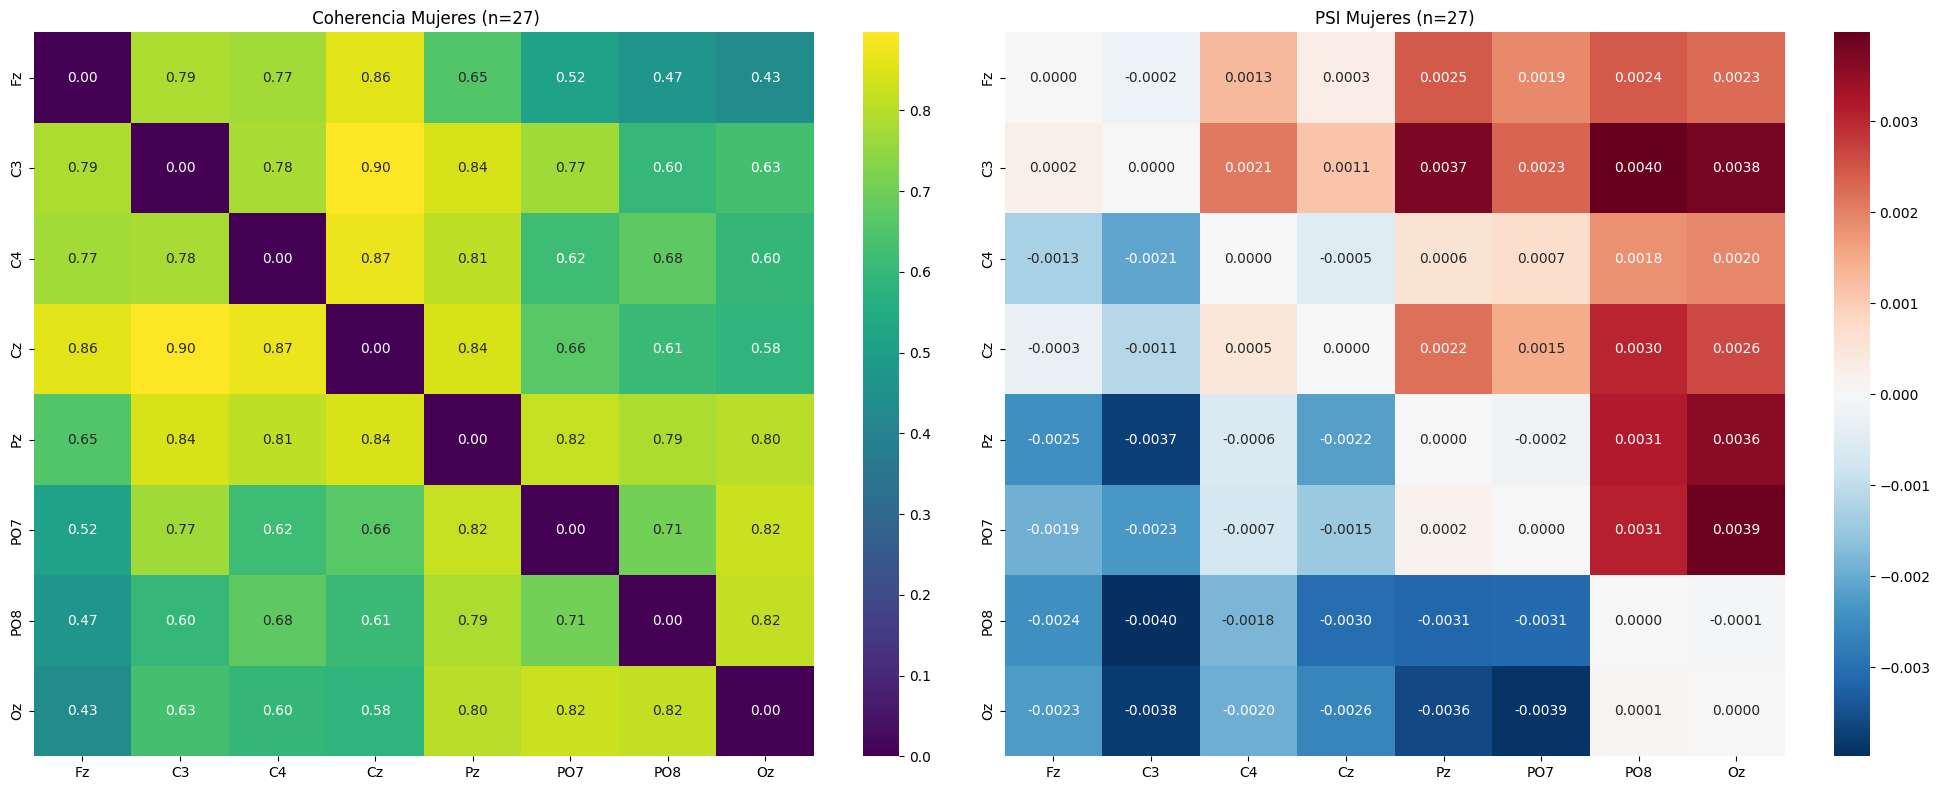

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def psi(sub_list, cwt_dir, freqs):
    #Configuración inicial
    control_subs = sub_list[sub_list['Gender'] == 'Female']['participant_id'].values
    target_channels = ['Fz', 'C3', 'C4', 'Cz', 'Pz', 'PO7', 'PO8', 'Oz']
    n_channels = len(target_channels)
    
    lista_coh_sujetos = []
    lista_psi_sujetos = []

    print(f"Procesando {len(control_subs)} sujetos...")

    for sub_id in control_subs:
        file_path = Path(cwt_dir) / f"{sub_id}_complex_zscore.npy"
        if not file_path.exists():
            continue

        # Cargar épocas
        epochs = np.load(file_path, allow_pickle=True)
        max_t_sub = max([e.shape[2] for e in epochs])

        sub_coh = np.zeros((n_channels, n_channels))
        sub_psi = np.zeros((n_channels, n_channels))

        # Cálculo de conectividad por pares de canales
        for i in range(n_channels):
            for j in range(i + 1, n_channels):
                # Matrices de acumulación para el promedio
                sum_Sxy = np.zeros((len(freqs), max_t_sub), dtype=complex)
                sum_Sxx = np.zeros((len(freqs), max_t_sub))
                sum_Syy = np.zeros((len(freqs), max_t_sub))
                counts = np.zeros(max_t_sub)

                for e in epochs:
                    t_size = e.shape[2]
                    Wx, Wy = e[i], e[j]
                    
                    # Acumulación de densidades espectrales
                    sum_Sxy[:, :t_size] += Wx * np.conj(Wy)
                    sum_Sxx[:, :t_size] += np.abs(Wx)**2
                    sum_Syy[:, :t_size] += np.abs(Wy)**2
                    counts[:t_size] += 1

                # Promedio ponderado por el número de épocas disponibles en cada punto t
                Sxy = sum_Sxy / (counts + 1e-15)
                Sxx = sum_Sxx / (counts + 1e-15)
                Syy = sum_Syy / (counts + 1e-15)

                # Coherencia Compleja y PSI
                Cxy = Sxy / (np.sqrt(Sxx * Syy) + 1e-15)
                sub_coh[i, j] = sub_coh[j, i] = np.abs(np.mean(Cxy))

                psi_vals = [np.imag(np.conj(Cxy[f]) * Cxy[f+1]) for f in range(len(freqs)-1)]
                val_psi = np.mean(psi_vals)
                sub_psi[i, j], sub_psi[j, i] = val_psi, -val_psi

        lista_coh_sujetos.append(sub_coh)
        lista_psi_sujetos.append(sub_psi)
        print(f" OK: {sub_id}")

    # 4. Grand Average del Grupo
    ga_coh = np.mean(lista_coh_sujetos, axis=0)
    ga_psi = np.mean(lista_psi_sujetos, axis=0)

    # 5. Graficación de Matrices NXN
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # Heatmap Coherencia
    sns.heatmap(ga_coh, annot=True, fmt=".2f", cmap='viridis', ax=ax1,
                xticklabels=target_channels, yticklabels=target_channels)
    ax1.set_title(f" Coherencia Mujeres (n={len(lista_coh_sujetos)})")

    # Heatmap PSI
    sns.heatmap(ga_psi, annot=True, fmt=".4f", cmap='RdBu_r', center=0, ax=ax2,
                xticklabels=target_channels, yticklabels=target_channels)
    ax2.set_title(f"PSI Mujeres (n={len(lista_coh_sujetos)})")

    plt.tight_layout()
    plt.show()

psi(sub_list, CWT_DIR, freqs)

Calculando PSI temporal para 27 sujetos...


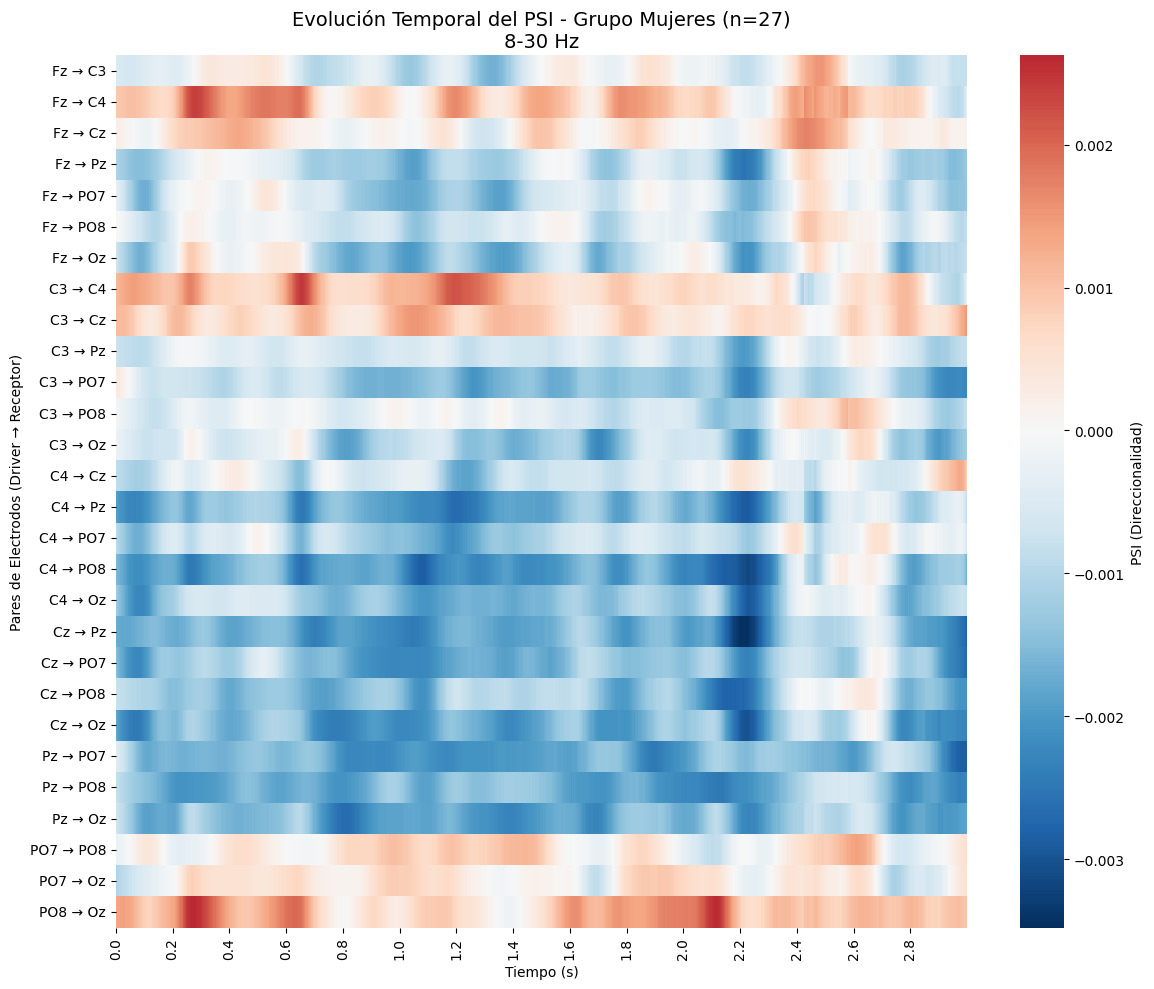

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def plot_group_psi_heatmap_3s(sub_list, cwt_dir, freqs, sfreq=250):
    # 1. Configuración de Sujetos y Canales
    control_subs = sub_list[sub_list['Gender'] == 'Female']['participant_id'].values
    target_channels = ['Fz', 'C3', 'C4', 'Cz', 'Pz', 'PO7', 'PO8', 'Oz']
    n_channels = len(target_channels)
    
    # Definir pares únicos de canales (Combinaciones N x N)
    pairs = [(target_channels[i], target_channels[j]) 
             for i in range(n_channels) for j in range(i + 1, n_channels)]
    n_pairs = len(pairs)
    
    # Límite de 3 segundos
    n_times_limit = int(3 * sfreq)
    times = np.arange(n_times_limit) / sfreq
    
    # Acumulador Grupal: (Sujetos, Pares, Tiempo)
    group_psi_data = np.full((len(control_subs), n_pairs, n_times_limit), np.nan)

    print(f"Calculando PSI temporal para {len(control_subs)} sujetos...")

    for s_idx, sub_id in enumerate(control_subs):
        file_path = Path(cwt_dir) / f"{sub_id}_complex_zscore.npy"
        if not file_path.exists(): continue

        # Cargar épocas
        epochs = np.load(file_path, allow_pickle=True)
        
        for p_idx, (ch_a, ch_b) in enumerate(pairs):
            idx_a, idx_b = target_channels.index(ch_a), target_channels.index(ch_b)
            
            # Acumuladores para el promedio
            sum_Sxy = np.zeros((len(freqs), n_times_limit), dtype=complex)
            sum_Sxx = np.zeros((len(freqs), n_times_limit))
            sum_Syy = np.zeros((len(freqs), n_times_limit))
            counts = np.zeros(n_times_limit)

            for e in epochs:
                t_size = min(e.shape[2], n_times_limit)
                Wx, Wy = e[idx_a, :, :t_size], e[idx_b, :, :t_size]
                
                # Densidades espectrales
                sum_Sxy[:, :t_size] += Wx * np.conj(Wy)
                sum_Sxx[:, :t_size] += np.abs(Wx)**2
                sum_Syy[:, :t_size] += np.abs(Wy)**2
                counts[:t_size] += 1

            # Calcular Coherencia Compleja
            valid = counts > 0
            Cxy = (sum_Sxy[:, valid] / counts[valid]) / \
                  (np.sqrt((sum_Sxx[:, valid] / counts[valid]) * (sum_Syy[:, valid] / counts[valid])) + 1e-15)

            # Calcular PSI por cada punto de tiempo
            psi_t_freqs = []
            for f in range(len(freqs) - 1):
                term = np.conj(Cxy[f, :]) * Cxy[f+1, :]
                psi_t_freqs.append(np.imag(term))
            
            # Guardar promedio de PSI en frecuencias
            group_psi_data[s_idx, p_idx, valid] = np.mean(psi_t_freqs, axis=0)

    # Grand Average del PSI
    ga_psi_temporal = np.nanmean(group_psi_data, axis=0)

    # Visualización como Heatmap
    plt.figure(figsize=(12, 10))
    pair_labels = [f"{p[0]} → {p[1]}" for p in pairs]
    
    sns.heatmap(ga_psi_temporal, xticklabels=25, yticklabels=pair_labels, 
                cmap='RdBu_r', center=0, cbar_kws={'label': 'PSI (Direccionalidad)'})
    
    plt.xticks(np.arange(0, n_times_limit, 50), np.round(np.arange(0, n_times_limit, 50)/sfreq, 1))
    
    plt.title(f"Evolución Temporal del PSI - Grupo Mujeres (n={len(control_subs)})\n8-30 Hz", fontsize=14)
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Pares de Electrodos (Driver → Receptor)")
    plt.tight_layout()
    plt.show()

#Ejecución

plot_group_psi_heatmap_3s(sub_list, CWT_DIR, freqs)

--- Iniciando Procesamiento de 27 sujetos ---
 Sujeto sub-03c finalizado.
 Sujeto sub-07c finalizado.
 Sujeto sub-10c finalizado.
 Sujeto sub-13c finalizado.
 Sujeto sub-15c finalizado.
 Sujeto sub-19c finalizado.
 Sujeto sub-20c finalizado.
 Sujeto sub-21c finalizado.
 Sujeto sub-22c finalizado.
 Sujeto sub-23c finalizado.
 Sujeto sub-01e finalizado.
 Sujeto sub-02e finalizado.
 Sujeto sub-03e finalizado.
 Sujeto sub-07e finalizado.
 Sujeto sub-08e finalizado.
 Sujeto sub-11e finalizado.
 Sujeto sub-16e finalizado.
 Sujeto sub-21e finalizado.
 Sujeto sub-22e finalizado.
 Sujeto sub-23e finalizado.
 Sujeto sub-26e finalizado.
 Sujeto sub-27e finalizado.
 Sujeto sub-28e finalizado.
 Sujeto sub-31e finalizado.
 Sujeto sub-38e finalizado.
 Sujeto sub-42e finalizado.
 Sujeto sub-43e finalizado.

Ejecutando Validación Jackknife...


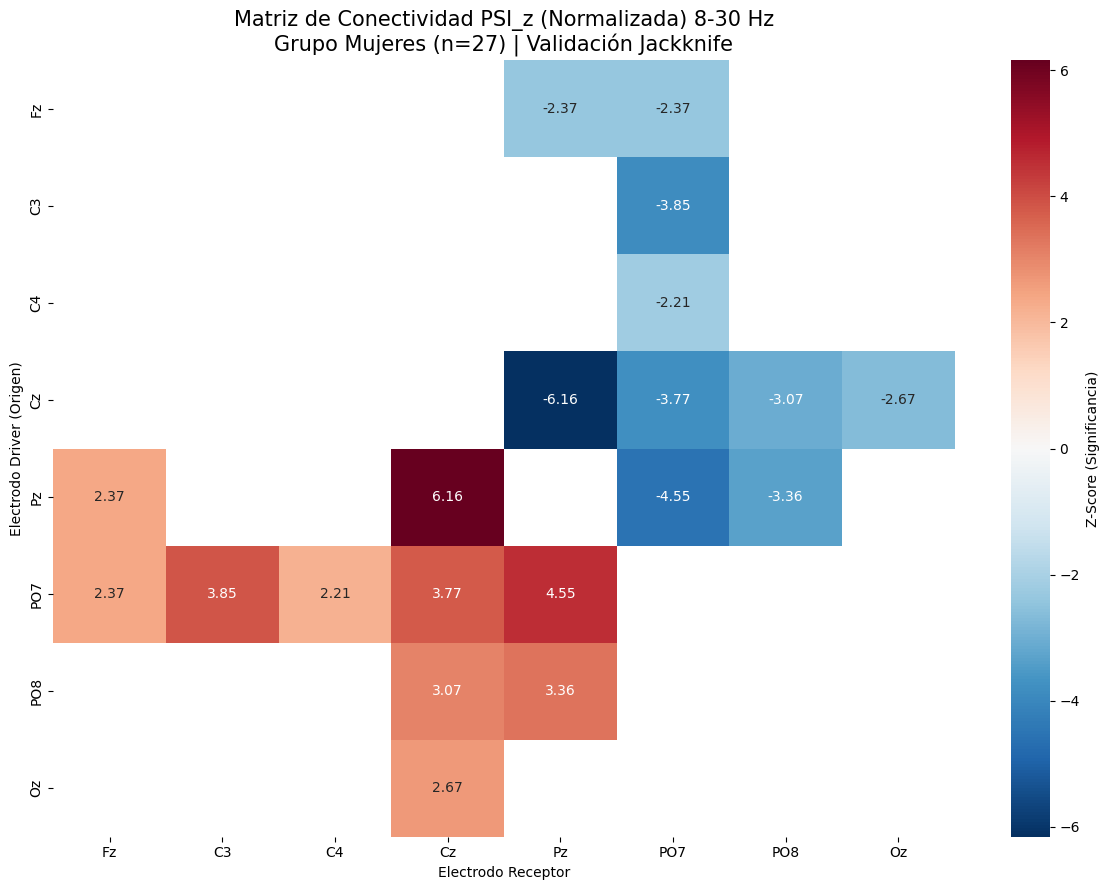

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

def pipeline_psi_jackknife(sub_list, cwt_dir, freqs, sfreq=250):
    # 1. Configuración de Sujetos y Canales
    control_subs = sub_list[sub_list['Gender'] == 'Female']['participant_id'].values
    target_channels = ['Fz', 'C3', 'C4', 'Cz', 'Pz', 'PO7', 'PO8', 'Oz']
    n_channels = len(target_channels)
    n_subs = len(control_subs)
    
    lista_psi_sujetos = []

    print(f"--- Iniciando Procesamiento de {n_subs} sujetos ---")

    for sub_id in control_subs:
        file_path = Path(cwt_dir) / f"{sub_id}_complex_zscore.npy"
        if not file_path.exists(): continue

        # Cargar épocas
        epochs = np.load(file_path, allow_pickle=True)
        max_t_sub = max([e.shape[2] for e in epochs])
        
        sub_psi_matrix = np.zeros((n_channels, n_channels))

        # Cálculo por pares de canales (i, j)
        for i in range(n_channels):
            for j in range(i + 1, n_channels):
                # Inicializar acumuladores para el promedio de épocas
                sum_Sxy = np.zeros((len(freqs), max_t_sub), dtype=complex)
                sum_Sxx = np.zeros((len(freqs), max_t_sub))
                sum_Syy = np.zeros((len(freqs), max_t_sub))
                counts = np.zeros(max_t_sub)

                for e in epochs:
                    t_size = e.shape[2]
                    Wx, Wy = e[i], e[j]
                    
                    # Densidad Espectral Cruzada y Autoespectros
                    sum_Sxy[:, :t_size] += Wx * np.conj(Wy)
                    sum_Sxx[:, :t_size] += np.abs(Wx)**2
                    sum_Syy[:, :t_size] += np.abs(Wy)**2
                    counts[:t_size] += 1

                # Coherencia Compleja Cxy(f,t)
                Sxy = sum_Sxy / (counts + 1e-15)
                Sxx = sum_Sxx / (counts + 1e-15)
                Syy = sum_Syy / (counts + 1e-15)
                Cxy = Sxy / (np.sqrt(Sxx * Syy) + 1e-15)

                # Cálculo de PSI para cada punto de tiempo t
                # Integrar sobre las frecuencias (f_min a f_max - df)
                psi_t_freqs = []
                for f_idx in range(len(freqs) - 1):
                    # Formula: Imag( conj(Cxy(f)) * Cxy(f+df) )
                    term = np.conj(Cxy[f_idx, :]) * Cxy[f_idx + 1, :]
                    psi_t_freqs.append(np.imag(term))
                
                # Promedio tiempo y frecuencia para obtener el escalar del sujeto
                val_psi = np.mean(psi_t_freqs)
                sub_psi_matrix[i, j] = val_psi
                sub_psi_matrix[j, i] = -val_psi # Propiedad antisimétrica

        lista_psi_sujetos.append(sub_psi_matrix)
        print(f" Sujeto {sub_id} finalizado.")

    #VALIDACIÓN JACKKNIFE
    print("\nEjecutando Validación Jackknife...")
    lista_psi_sujetos = np.array(lista_psi_sujetos)
    
    #Excluir i por cada iteración
    jack_means = np.array([np.mean(np.delete(lista_psi_sujetos, i, axis=0), axis=0) for i in range(n_subs)])
    ga_psi = np.mean(lista_psi_sujetos, axis=0) # Promedio real del grupo

    # Calcular desviación estándar de Jackknife (sigma_jack)
    diff_sq = (jack_means - ga_psi)**2
    sigma_jack = np.sqrt(((n_subs - 1) / n_subs) * np.sum(diff_sq, axis=0))

    # 12. Normalización -> PSI_z = PSI / sigma_jack
    psi_z = ga_psi / (sigma_jack + 1e-15)

    #Visualización de Resultados
    plt.figure(figsize=(12, 9))
    
    # Umbral de significancia estadística (p < 0.05)
    t_crit = stats.t.ppf(1 - 0.05/2, n_subs - 1)
    mask = np.abs(psi_z) < t_crit # Ocultar lo que no es significativo

    sns.heatmap(psi_z, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
                mask=mask, xticklabels=target_channels, yticklabels=target_channels,
                cbar_kws={'label': 'Z-Score (Significancia)'})

    plt.title(f"Matriz de Conectividad PSI_z (Normalizada) 8-30 Hz\nGrupo Mujeres (n={n_subs}) | Validación Jackknife", fontsize=15)
    plt.xlabel("Electrodo Receptor")
    plt.ylabel("Electrodo Driver (Origen)")
    plt.tight_layout()
    plt.show()

    return psi_z

# Ejecución
matriz_final_z = pipeline_psi_jackknife(sub_list, CWT_DIR, freqs)

--- Procesando PSI de 21 mujeres para gráfica global (Todos vs Todos) ---
 Sujeto sub-01c procesado.
 Sujeto sub-02c procesado.
 Sujeto sub-04c procesado.
 Sujeto sub-05c procesado.
 Sujeto sub-06c procesado.
 Sujeto sub-08c procesado.
 Sujeto sub-09c procesado.
 Sujeto sub-11c procesado.
 Sujeto sub-12c procesado.
 Sujeto sub-18c procesado.
 Sujeto sub-24c procesado.
 Sujeto sub-04e procesado.
 Sujeto sub-05e procesado.
 Sujeto sub-06e procesado.
 Sujeto sub-09e procesado.
 Sujeto sub-13e procesado.
 Sujeto sub-17e procesado.
 Sujeto sub-18e procesado.
 Sujeto sub-19e procesado.
 Sujeto sub-20e procesado.
 Sujeto sub-29e procesado.


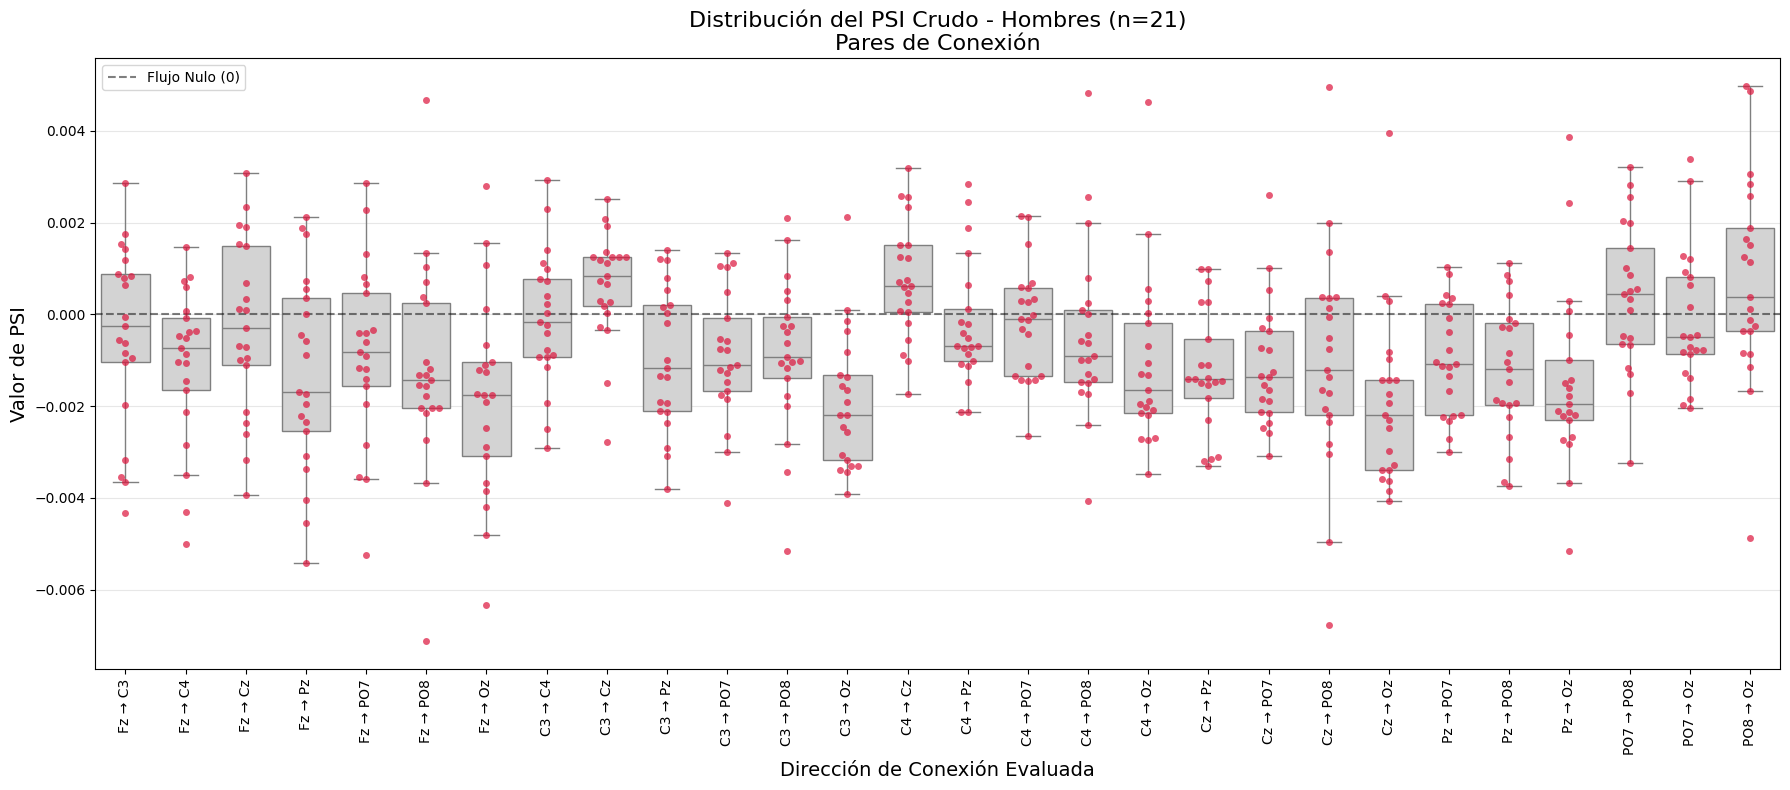

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def boxplot(sub_list, cwt_dir, freqs, sfreq=250):
    # 1. Configuración de Sujetos y Canales
    control_subs = sub_list[sub_list['Gender'] == 'Male']['participant_id'].values
    target_channels = ['Fz', 'C3', 'C4', 'Cz', 'Pz', 'PO7', 'PO8', 'Oz']
    n_channels = len(target_channels)
    n_subs = len(control_subs)
    
    lista_psi_sujetos = []

    print(f"--- Procesando PSI de {n_subs} mujeres para gráfica global (Todos vs Todos) ---")

    for sub_id in control_subs:
        file_path = Path(cwt_dir) / f"{sub_id}_complex_zscore.npy" # Asegúrate que tu archivo crudo siga llamándose así
        if not file_path.exists(): continue

        # Cargar épocas
        epochs = np.load(file_path, allow_pickle=True)
        max_t_sub = max([e.shape[2] for e in epochs])
        
        sub_psi_matrix = np.zeros((n_channels, n_channels))

        # Cálculo por pares únicos de canales (i, j) donde j siempre es mayor que i
        for i in range(n_channels):
            for j in range(i + 1, n_channels):
                sum_Sxy = np.zeros((len(freqs), max_t_sub), dtype=complex)
                sum_Sxx = np.zeros((len(freqs), max_t_sub))
                sum_Syy = np.zeros((len(freqs), max_t_sub))
                counts = np.zeros(max_t_sub)

                for e in epochs:
                    t_size = e.shape[2]
                    Wx, Wy = e[i], e[j]
                    
                    sum_Sxy[:, :t_size] += Wx * np.conj(Wy)
                    sum_Sxx[:, :t_size] += np.abs(Wx)**2
                    sum_Syy[:, :t_size] += np.abs(Wy)**2
                    counts[:t_size] += 1

                Sxy = sum_Sxy / (counts + 1e-15)
                Sxx = sum_Sxx / (counts + 1e-15)
                Syy = sum_Syy / (counts + 1e-15)
                Cxy = Sxy / (np.sqrt(Sxx * Syy) + 1e-15)

                psi_t_freqs = []
                for f_idx in range(len(freqs) - 1):
                    term = np.conj(Cxy[f_idx, :]) * Cxy[f_idx + 1, :]
                    psi_t_freqs.append(np.imag(term))
                
                val_psi = np.mean(psi_t_freqs)
                sub_psi_matrix[i, j] = val_psi
                sub_psi_matrix[j, i] = -val_psi

        lista_psi_sujetos.append(sub_psi_matrix)
        print(f" Sujeto {sub_id} procesado.")

    # --- EXTRACCIÓN DE DATOS: ITERAR SOLO SOBRE PARES ÚNICOS ---
    datos_plot = []
    
    # Recorremos igual que el cálculo: i, y luego j a partir de i+1
    for i in range(n_channels):
        for j in range(i + 1, n_channels):
            ch_origen = target_channels[i]
            ch_destino = target_channels[j]
            nombre_conexion = f"{ch_origen} → {ch_destino}"
            
            # Extraemos este par para todos los sujetos
            for s_idx, matriz in enumerate(lista_psi_sujetos):
                datos_plot.append({
                    'Sujeto': s_idx + 1,
                    'PSI_Crudo': matriz[i, j],
                    'Conexión': nombre_conexion
                })
                
    # Convertimos a DataFrame para Seaborn
    df_plot = pd.DataFrame(datos_plot)
    
    # --- VISUALIZACIÓN GLOBAL ---
    # Usamos una figura ancha para que las 28 cajas respiren bien
    plt.figure(figsize=(18, 8)) 
    
    # Boxplot base (mediana y cuartiles)
    sns.boxplot(data=df_plot, x='Conexión', y='PSI_Crudo', 
                color='lightgray', showfliers=False)
    
    # Swarmplot superpuesto (puntos más pequeños para evitar solapamiento masivo)
    sns.swarmplot(data=df_plot, x='Conexión', y='PSI_Crudo', 
                  color='crimson', size=5, alpha=0.7)
    
    # Línea de referencia en cero
    plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Flujo Nulo (0)')
    
    plt.title(f"Distribución del PSI Crudo - Hombres (n={n_subs})\nPares de Conexión", fontsize=16)
    plt.ylabel("Valor de PSI", fontsize=14)
    plt.xlabel("Dirección de Conexión Evaluada", fontsize=14)
    
    # Rotamos las etiquetas del eje X a 90 grados para que el texto de las 28 conexiones no se empalme
    plt.xticks(rotation=90, fontsize=10)
    
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_plot

# --- Ejecución ---
df_resultados_globales = boxplot(sub_list, CWT_DIR, freqs)

--- Iniciando Procesamiento (Bootstrap de 2 Niveles) en 21 sujetos ---
Iteraciones Bootstrap por par de canales: 10
 Sujeto sub-01c finalizado (Nivel 1 completado).
 Sujeto sub-02c finalizado (Nivel 1 completado).
 Sujeto sub-04c finalizado (Nivel 1 completado).
 Sujeto sub-05c finalizado (Nivel 1 completado).
 Sujeto sub-06c finalizado (Nivel 1 completado).
 Sujeto sub-08c finalizado (Nivel 1 completado).
 Sujeto sub-09c finalizado (Nivel 1 completado).
 Sujeto sub-11c finalizado (Nivel 1 completado).
 Sujeto sub-12c finalizado (Nivel 1 completado).
 Sujeto sub-18c finalizado (Nivel 1 completado).
 Sujeto sub-24c finalizado (Nivel 1 completado).
 Sujeto sub-04e finalizado (Nivel 1 completado).
 Sujeto sub-05e finalizado (Nivel 1 completado).
 Sujeto sub-06e finalizado (Nivel 1 completado).
 Sujeto sub-09e finalizado (Nivel 1 completado).
 Sujeto sub-13e finalizado (Nivel 1 completado).
 Sujeto sub-17e finalizado (Nivel 1 completado).
 Sujeto sub-18e finalizado (Nivel 1 completado).
 S

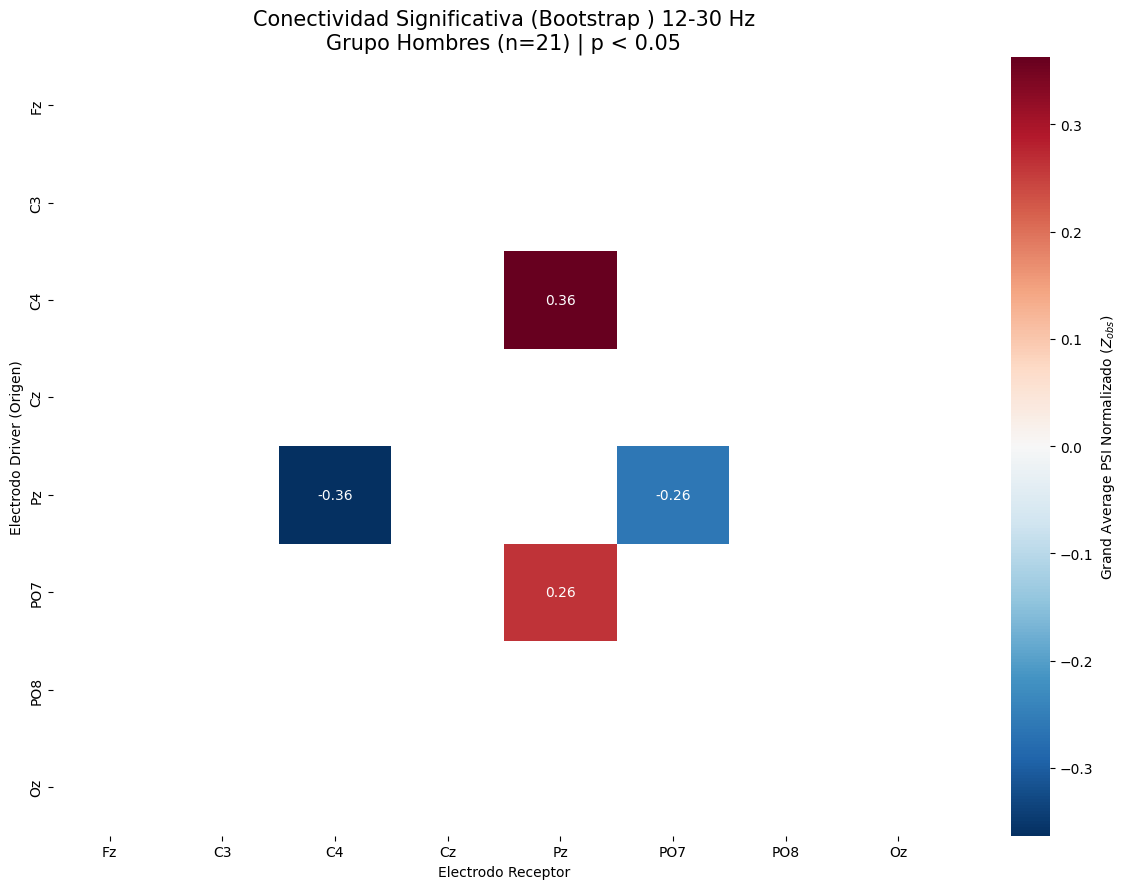

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

def pipeline_psi_bootstrap(sub_list, cwt_dir, freqs, n_boot=200, sfreq=250):
    # 1. Configuración de Sujetos y Canales
    control_subs = sub_list[sub_list['Gender'] == 'Male']['participant_id'].values
    target_channels = ['Fz', 'C3', 'C4', 'Cz', 'Pz', 'PO7', 'PO8', 'Oz']
    n_channels = len(target_channels)
    n_subs = len(control_subs)
    
    lista_psi_norm_sujetos = []

    print(f"--- Iniciando Procesamiento (Bootstrap de 2 Niveles) en {n_subs} sujetos ---")
    print(f"Iteraciones Bootstrap por par de canales: {n_boot}")

    for sub_id in control_subs:
        file_path = Path(cwt_dir) / f"{sub_id}_complex_zscore.npy"
        if not file_path.exists(): continue

        # Cargar épocas
        epochs = np.load(file_path, allow_pickle=True)
        n_epochs = len(epochs)
        max_t_sub = max([e.shape[2] for e in epochs])
        
        sub_psi_norm_matrix = np.zeros((n_channels, n_channels))

        # Cálculo por pares de canales (i, j)
        for i in range(n_channels):
            for j in range(i + 1, n_channels):
                
                # OPTIMIZACIÓN: Pre-calcular los espectros de cada época individual
                # Esto evita hacer las multiplicaciones complejas n_boot veces
                epoch_Sxy = np.zeros((n_epochs, len(freqs), max_t_sub), dtype=complex)
                epoch_Sxx = np.zeros((n_epochs, len(freqs), max_t_sub))
                epoch_Syy = np.zeros((n_epochs, len(freqs), max_t_sub))
                epoch_counts = np.zeros((n_epochs, max_t_sub))

                for e_idx, e in enumerate(epochs):
                    t_size = e.shape[2]
                    Wx, Wy = e[i], e[j]
                    
                    epoch_Sxy[e_idx, :, :t_size] = Wx * np.conj(Wy)
                    epoch_Sxx[e_idx, :, :t_size] = np.abs(Wx)**2
                    epoch_Syy[e_idx, :, :t_size] = np.abs(Wy)**2
                    epoch_counts[e_idx, :t_size] = 1 # Para saber cuántas épocas aportaron a cada ms

                # --- A. CÁLCULO DE PSI OBSERVADO (Usando todas las épocas) ---
                sum_Sxy = np.sum(epoch_Sxy, axis=0)
                sum_Sxx = np.sum(epoch_Sxx, axis=0)
                sum_Syy = np.sum(epoch_Syy, axis=0)
                counts = np.sum(epoch_counts, axis=0)

                Sxy = sum_Sxy / (counts + 1e-15)
                Sxx = sum_Sxx / (counts + 1e-15)
                Syy = sum_Syy / (counts + 1e-15)
                Cxy = Sxy / (np.sqrt(Sxx * Syy) + 1e-15)

                psi_t_freqs = []
                for f_idx in range(len(freqs) - 1):
                    term = np.conj(Cxy[f_idx, :]) * Cxy[f_idx + 1, :]
                    psi_t_freqs.append(np.imag(term))
                val_psi_obs = np.mean(psi_t_freqs)

                # --- B. NIVEL 1: BOOTSTRAP INTRA-SUJETO ---
                boot_vals = np.zeros(n_boot)
                for b in range(n_boot):
                    # Remuestreo con reemplazo de los índices de las épocas
                    idx = np.random.choice(n_epochs, size=n_epochs, replace=True)
                    
                    b_sum_Sxy = np.sum(epoch_Sxy[idx], axis=0)
                    b_sum_Sxx = np.sum(epoch_Sxx[idx], axis=0)
                    b_sum_Syy = np.sum(epoch_Syy[idx], axis=0)
                    b_counts = np.sum(epoch_counts[idx], axis=0)

                    b_Sxy = b_sum_Sxy / (b_counts + 1e-15)
                    b_Sxx = b_sum_Sxx / (b_counts + 1e-15)
                    b_Syy = b_sum_Syy / (b_counts + 1e-15)
                    b_Cxy = b_Sxy / (np.sqrt(b_Sxx * b_Syy) + 1e-15)

                    b_psi_t_freqs = []
                    for f_idx in range(len(freqs) - 1):
                        term = np.conj(b_Cxy[f_idx, :]) * b_Cxy[f_idx + 1, :]
                        b_psi_t_freqs.append(np.imag(term))
                    
                    boot_vals[b] = np.mean(b_psi_t_freqs)

                # --- C. NORMALIZACIÓN Z-SCORE DEL SUJETO ---
                mu_boot = np.mean(boot_vals)
                sigma_boot = np.std(boot_vals) + 1e-15
                
                psi_norm_s = (val_psi_obs - mu_boot) / sigma_boot
                
                # Asignar a la matriz del sujeto (antisimetría)
                sub_psi_norm_matrix[i, j] = psi_norm_s
                sub_psi_norm_matrix[j, i] = -psi_norm_s

        lista_psi_norm_sujetos.append(sub_psi_norm_matrix)
        print(f" Sujeto {sub_id} finalizado (Nivel 1 completado).")

    # ==========================================
    # --- NIVEL 2: ANÁLISIS INTER-SUJETO ---
    # ==========================================
    print("\nEjecutando Nivel 2: Estadísticas de Grupo...")
    lista_psi_norm_sujetos = np.array(lista_psi_norm_sujetos) # Forma: (Sujetos, Canales, Canales)
    
    # 1. Promedio Grupal (Grand Average Z-score)
    ga_psi_norm = np.mean(lista_psi_norm_sujetos, axis=0)
    
    # 2. Prueba T de una muestra (One-Sample T-Test) contra 0
    # Evaluamos si el promedio de Z-scores de la muestra es significativamente distinto de 0
    t_vals, p_vals = stats.ttest_1samp(lista_psi_norm_sujetos, popmean=0, axis=0)

    # --- VISUALIZACIÓN DE RESULTADOS ---
    plt.figure(figsize=(12, 9))
    
    # Crear máscara para ocultar conexiones que NO son significativas (p >= 0.05)
    alpha_level = 0.05
    mask = p_vals >= alpha_level
    
    # Para la diagonal (que da NaN en t-test porque siempre es 0), forzamos ocultarla
    np.fill_diagonal(mask, True)

    sns.heatmap(ga_psi_norm, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
                mask=mask, xticklabels=target_channels, yticklabels=target_channels,
                cbar_kws={'label': 'Grand Average PSI Normalizado ($Z_{obs}$)'})

    plt.title(f"Conectividad Significativa (Bootstrap ) 12-30 Hz\nGrupo Hombres (n={n_subs}) | p < {alpha_level}", fontsize=15)
    plt.xlabel("Electrodo Receptor")
    plt.ylabel("Electrodo Driver (Origen)")
    plt.tight_layout()
    plt.show()

    return ga_psi_norm, p_vals, lista_psi_norm_sujetos

# Ejecución
ga_psi, p_values, sujetos_z = pipeline_psi_bootstrap(sub_list, CWT_DIR, freqs, n_boot=10)